In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import graphviz

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_graphviz

from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression

In [4]:
spotify = pd.read_csv("/content/spotify_cleaned.csv")
spotify

,Position,Artist Name,Song Name,Days Since Released,Top 10 (xTimes),Peak Position,Peak Position (xTimes),Peak Streams,Total Streams
0,1,Post Malone,Sunflower SpiderMan: Into the SpiderVerse,1506,302,1,(x29),2118242,883369738
1,2,Juice WRLD,Lucid Dreams,1673,178,1,(x20),2127668,864832399
2,3,Lil Uzi Vert,XO TOUR Llif3,1853,212,1,(x4),1660502,781153024
3,4,J. Cole,No Role Modelz,2547,6,7,0,659366,734857487
4,5,Post Malone,rockstar,1223,186,1,(x124),2905678,718865961
...,...,...,...,...,...,...,...,...,...
11079,11080,The Band Perry,If I Die Young,1,0,184,0,51321,51321
11080,11081,Justin Timberlake,Not a Bad Thing,1,0,196,0,49512,49512
11081,11082,Mike WiLL Made,It 23,1,0,167,0,46547,46547
11082,11083,The Vamps,Somebody To You,1,0,200,0,44962,44962


In [5]:
spotify_clean = spotify.dropna()
spotify_clean

,Position,Artist Name,Song Name,Days Since Released,Top 10 (xTimes),Peak Position,Peak Position (xTimes),Peak Streams,Total Streams
0,1,Post Malone,Sunflower SpiderMan: Into the SpiderVerse,1506,302,1,(x29),2118242,883369738
1,2,Juice WRLD,Lucid Dreams,1673,178,1,(x20),2127668,864832399
2,3,Lil Uzi Vert,XO TOUR Llif3,1853,212,1,(x4),1660502,781153024
3,4,J. Cole,No Role Modelz,2547,6,7,0,659366,734857487
4,5,Post Malone,rockstar,1223,186,1,(x124),2905678,718865961
...,...,...,...,...,...,...,...,...,...
11079,11080,The Band Perry,If I Die Young,1,0,184,0,51321,51321
11080,11081,Justin Timberlake,Not a Bad Thing,1,0,196,0,49512,49512
11081,11082,Mike WiLL Made,It 23,1,0,167,0,46547,46547
11082,11083,The Vamps,Somebody To You,1,0,200,0,44962,44962


In [6]:
spotify = pd.get_dummies(spotify_clean, columns = ["Artist Name", "Song Name", "Peak Position (xTimes)"], drop_first = True)
spotify

,Position,Days Since Released,Top 10 (xTimes),Peak Position,Peak Streams,Total Streams,Artist Name_$ilkMoney,Artist Name_$uicideboy$,Artist Name_*NSYNC,Artist Name_100 gecs,...,Peak Position (xTimes)_(x64),Peak Position (xTimes)_(x65),Peak Position (xTimes)_(x66),Peak Position (xTimes)_(x67),Peak Position (xTimes)_(x7),Peak Position (xTimes)_(x70),Peak Position (xTimes)_(x8),Peak Position (xTimes)_(x85),Peak Position (xTimes)_(x9),Peak Position (xTimes)_0
0,1,1506,302,1,2118242,883369738,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,1673,178,1,2127668,864832399,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,1853,212,1,1660502,781153024,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,2547,6,7,659366,734857487,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5,1223,186,1,2905678,718865961,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11079,11080,1,0,184,51321,51321,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
11080,11081,1,0,196,49512,49512,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
11081,11082,1,0,167,46547,46547,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
11082,11083,1,0,200,44962,44962,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [7]:
x = spotify.drop(columns=["Total Streams", "Position", "Peak Streams", "Peak Position"])
y = spotify["Peak Streams"]

In [8]:
model = DecisionTreeRegressor(max_depth = 3)
model.fit(x, y)

DecisionTreeRegressor(max_depth=3)

[Text(0.5, 0.875, 'x[1] <= 0.5\nsquared_error = 394711163592.509\nsamples = 11080\nvalue = 552885.371'),
 Text(0.25, 0.625, 'x[0] <= 4.5\nsquared_error = 101555379300.829\nsamples = 9851\nvalue = 404468.653'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[0] <= 1.5\nsquared_error = 15873819823.094\nsamples = 4651\nvalue = 280485.434'),
 Text(0.0625, 0.125, 'squared_error = 6963033136.705\nsamples = 2453\nvalue = 239496.223'),
 Text(0.1875, 0.125, 'squared_error = 21850789944.297\nsamples = 2198\nvalue = 326229.989'),
 Text(0.375, 0.375, 'x[1372] <= 0.5\nsquared_error = 152144658166.083\nsamples = 5200\nvalue = 515362.106'),
 Text(0.3125, 0.125, 'squared_error = 133269646614.996\nsamples = 5114\nvalue = 502706.763'),
 Text(0.4375, 0.125, 'squared_error = 698691965662.365\nsamples = 86\nvalue = 1267913.535'),
 Text(0.75, 0.625, 'x[11655] <= 0.5\nsquared_error = 1152713529964.18\nsamples = 1229\nvalue = 1742513.59'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[392] <= 0.5

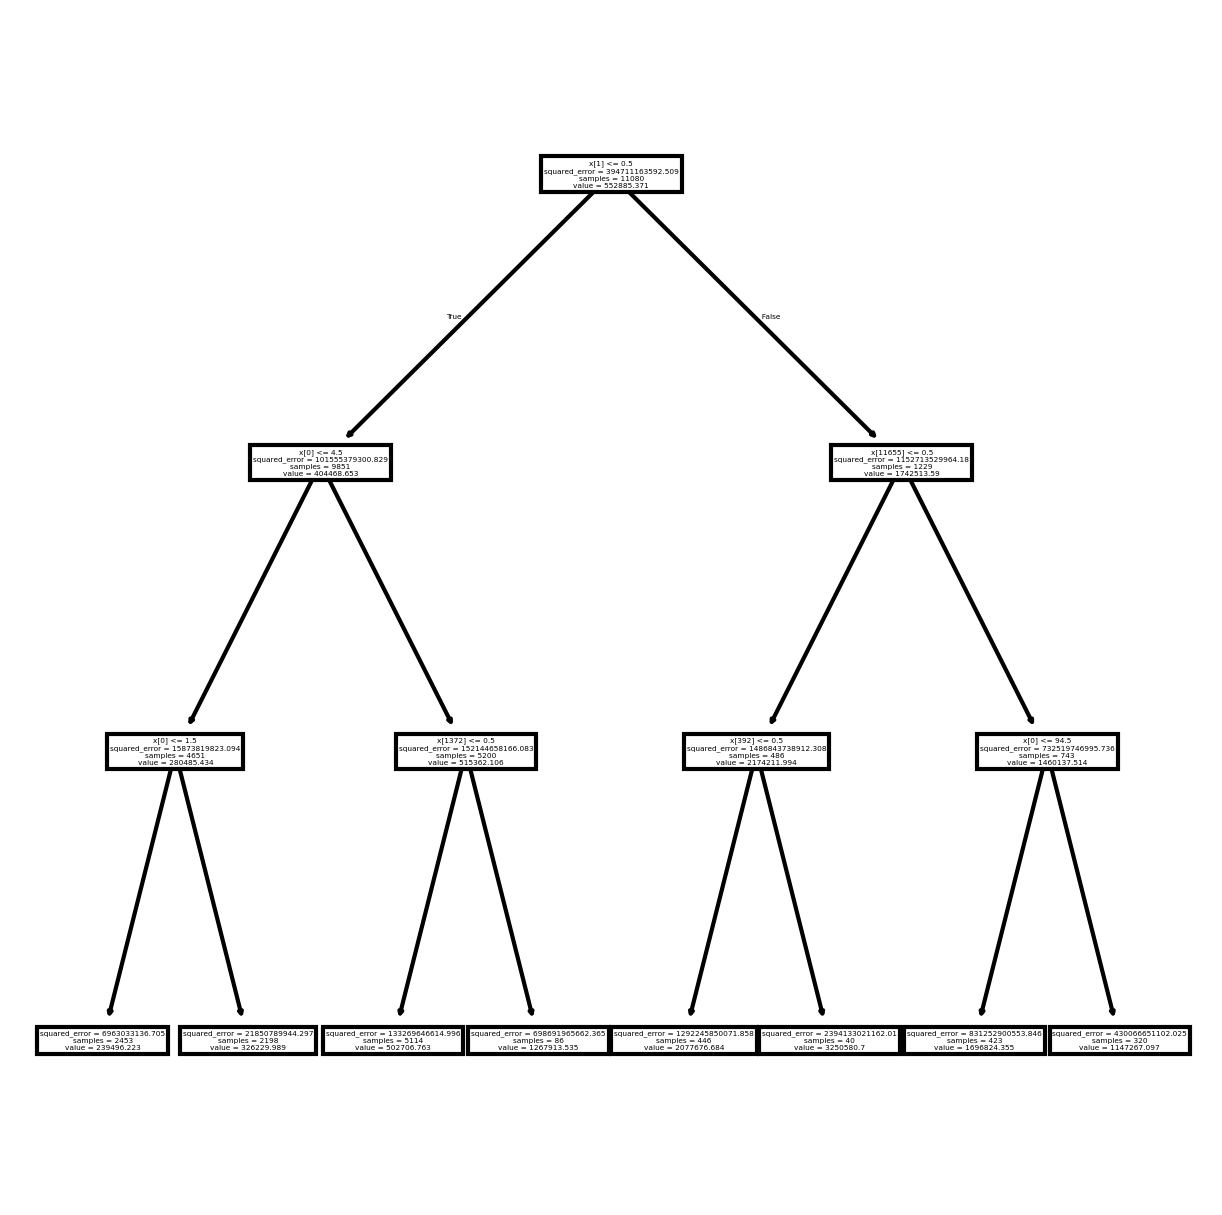

In [9]:
from sklearn.tree import plot_tree
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5), dpi=300)
plot_tree(model)

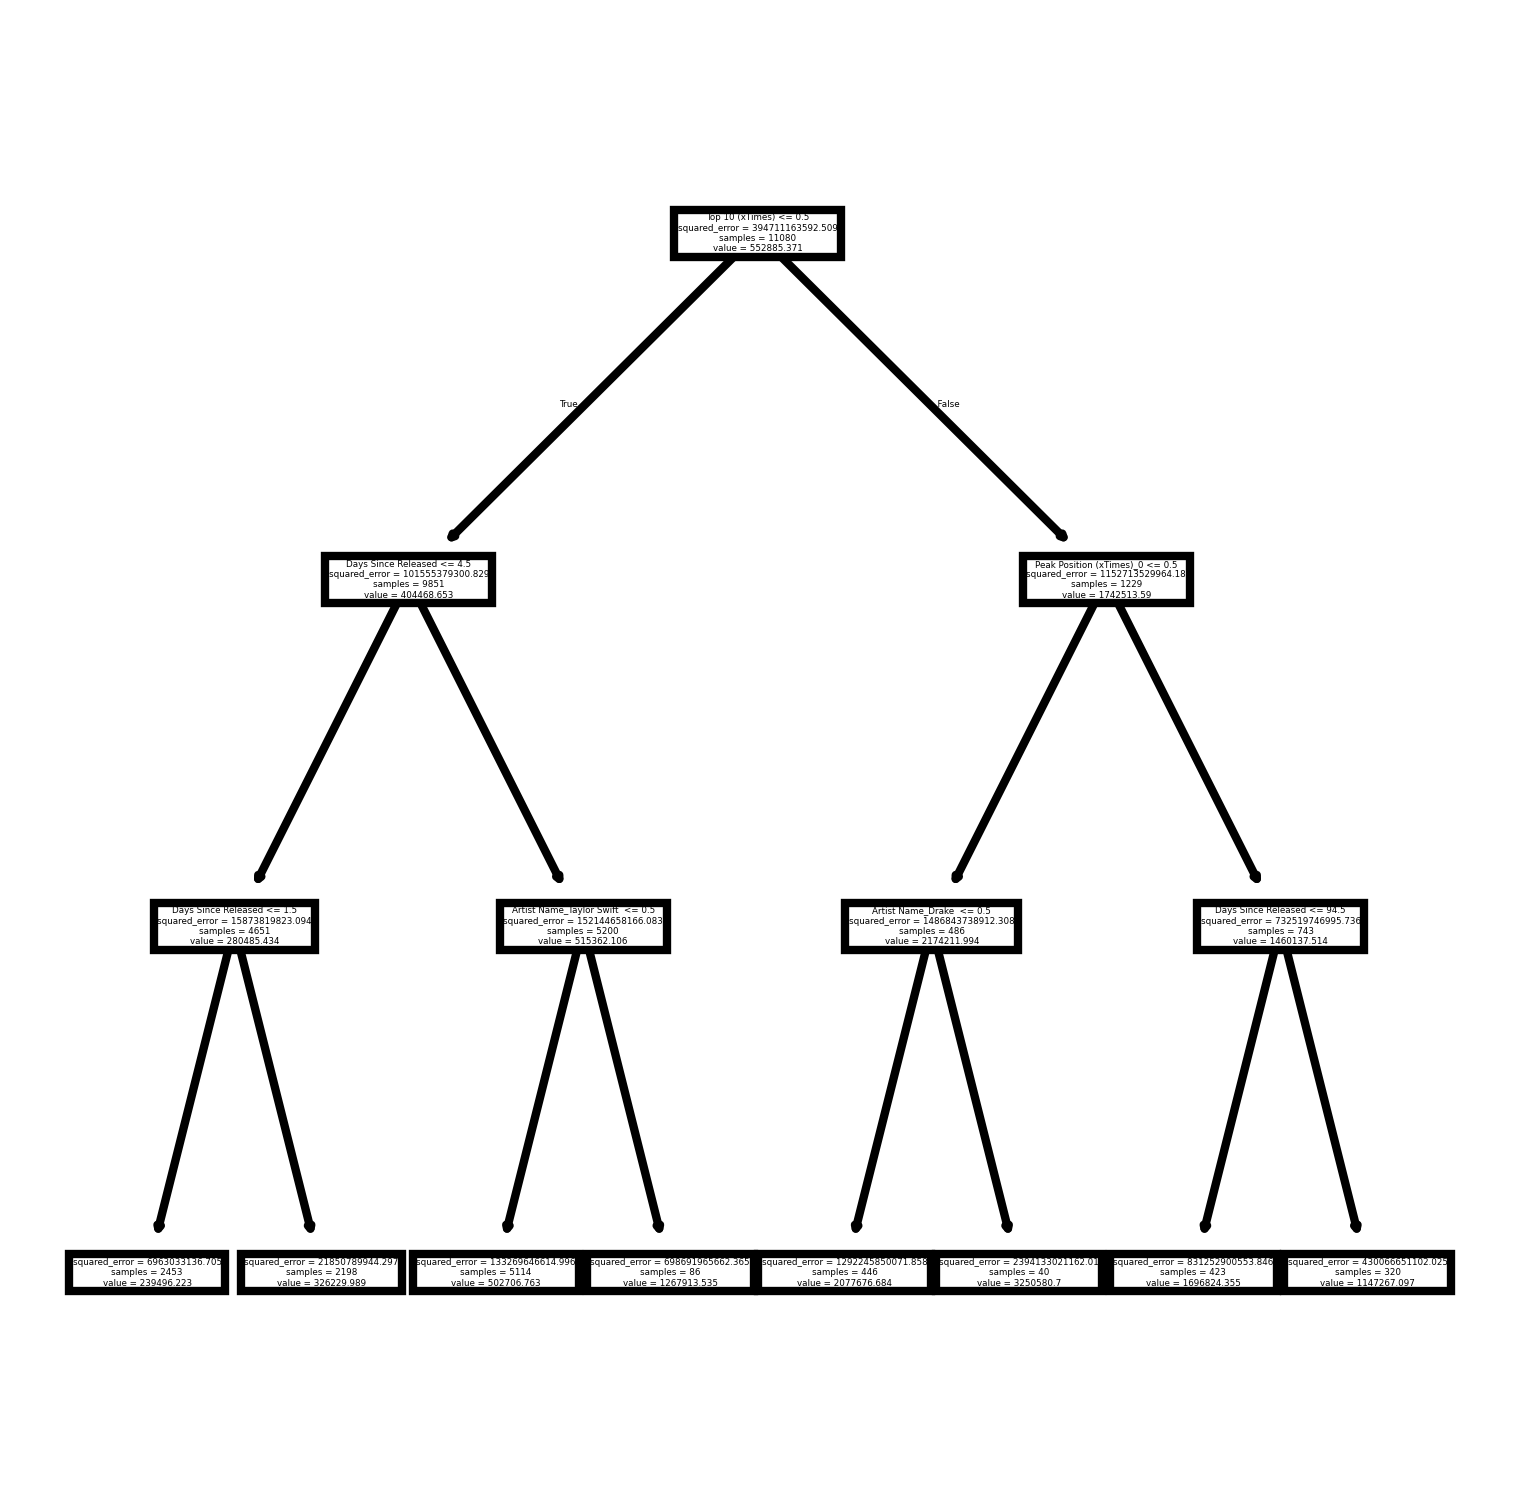

In [10]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (3,3), dpi=600)
_ = plot_tree(model, feature_names = x.columns)

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [12]:
tree_model = DecisionTreeRegressor(max_depth = 3)
tree_model.fit(x_train, y_train)
predictions = tree_model.predict(x_test)

In [13]:
train_predict = tree_model.predict(x_train)

In [14]:
print(f"This model's Testing MSE is {mean_squared_error(y_test, predictions)}")
print(f"This model's Training MSE is {mean_squared_error(y_train, train_predict)}")

This model's Testing MSE is 209399665325.55048
This model's Training MSE is 172200502830.34088


MSE for k =  1 done!
MSE for k =  2 done!
MSE for k =  3 done!
MSE for k =  4 done!
MSE for k =  5 done!
MSE for k =  6 done!
MSE for k =  7 done!
MSE for k =  8 done!
MSE for k =  9 done!
MSE for k =  10 done!
MSE for k =  11 done!
MSE for k =  12 done!
MSE for k =  13 done!
MSE for k =  14 done!
MSE for k =  15 done!
MSE for k =  16 done!
MSE for k =  17 done!
MSE for k =  18 done!
MSE for k =  19 done!
MSE for k =  20 done!
MSE for k =  21 done!
MSE for k =  22 done!
MSE for k =  23 done!
MSE for k =  24 done!


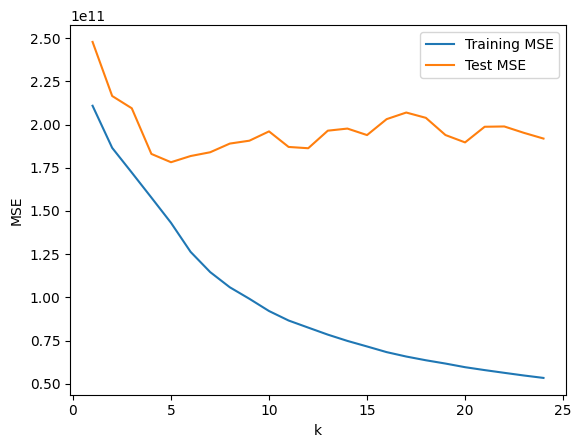

In [16]:
k_vals = range(1, 25)
mse_train_list = []
mse_test_list = []

for k in k_vals:
    tree_mod = DecisionTreeRegressor(max_depth=k)
    tree_mod.fit(x_train, y_train)

    pred_train = tree_mod.predict(x_train)
    pred_test = tree_mod.predict(x_test)

    mse_train_list.append(mean_squared_error(y_train, pred_train))
    mse_test_list.append(mean_squared_error(y_test, pred_test))
    print("MSE for k = ", k, "done!")

plt.plot(k_vals, mse_train_list, label="Training MSE")
plt.plot(k_vals, mse_test_list, label="Test MSE")
plt.xlabel("k")
plt.ylabel("MSE")
plt.legend()
plt.show()